# Retrieval Analysis — PDF `1804_03_21_1804032150`

Single-PDF retrieval study for the BSARD questions whose ground truth lives (at least partially) inside this PDF. The pipeline is the cached Arm-1 sliding-window run (config `5edcd3a09e09`):

| Setting | Value |
|---|---|
| Tokenizer / Embedder | `intfloat/multilingual-e5-large-instruct` |
| Chunking | sliding window, 512 tokens / 256 stride |
| Pool depth | top-200 RRF-fused (`k=60`) of dense + BM25 |
| Reranker | not applied — pool only |

Total chunk count (the size of the searched corpus for this PDF) is loaded in §1 and surfaced everywhere it matters for context.

## Ground truth used here

From [data/1804_03_21_1804032150/question_relevance.json](data/1804_03_21_1804032150/question_relevance.json), built earlier from [RQ2_T07_EVALUATION/ground_truth/question_extraction_status/questions_by_extraction_status.jsonl](../RQ2_T07_EVALUATION/ground_truth/question_extraction_status/questions_by_extraction_status.jsonl).

- **strict GT** = the GT `bsard_id`s with `verification_status == 'FOUND'` inside this PDF (the BSARD-canonical text matches the PDF text exactly).
- **lenient GT** = the GT `bsard_id`s with `verification_status ∈ {FOUND, PARTIAL}` inside this PDF (PARTIAL = present but with text differences, typically post-BSARD amendments).
- **relevant question** = lenient GT non-empty.

## Metrics

Article-level (a question "hits" at rank `r` if any retrieved chunk's `bsard_ids` overlaps the GT set):

- `recall@k` = `|GT ∩ retrieved_bsard_ids[:k]| / |GT|`
- `precision@k` = `|GT ∩ retrieved_bsard_ids[:k]| / k_unique` (deduplicated bsard_ids in the top-k chunks)
- `hit@k` = 1 if any GT article appears in the top-k chunks, else 0
- `MRR` = `1 / first_relevant_rank` (0 if no GT in pool)

Each metric is reported twice — strict and lenient — and broken down by `split` and `per_pdf_extraction_status`.

## 1. Load relevance, chunks corpus, retrieval pool

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DOC_ID = "1804_03_21_1804032150"
CONFIG_HASH = "5edcd3a09e09"
K_VALUES = [1, 5, 10, 20, 50, 100]


In [2]:
# Parameters
DOC_ID = "2003_07_17_2013A31614"
CONFIG_HASH = "614cc9425f5f"


In [3]:
HERE = Path.cwd()
DOC_DIR = HERE / "data" / DOC_ID
CONFIG_DIR = DOC_DIR / "configs" / CONFIG_HASH
POOL_DIR = DOC_DIR / "results" / CONFIG_HASH / "retrieval_pool"
RELEVANCE_PATH = DOC_DIR / "question_relevance.json"
OUT_DIR = DOC_DIR / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(RELEVANCE_PATH, encoding="utf-8") as fh:
    relevance = json.load(fh)

rel_questions = relevance["relevant_questions"]
rel_by_qid = {r["question_id"]: r for r in rel_questions}
print(f"Relevant questions: {len(rel_questions)}")
print(f"  train: {sum(1 for r in rel_questions if r['split'] == 'train')}")
print(f"  test:  {sum(1 for r in rel_questions if r['split'] == 'test')}")
print(f"  per-PDF buckets: {relevance['summary']['per_pdf_bucket_counts']}")


Relevant questions: 136
  train: 102
  test:  34
  per-PDF buckets: {'partial': 124, 'mixed': 12}


In [4]:
# --- corpus: total chunks in this PDF (the pool of candidates retrieval searches) ---
with open(CONFIG_DIR / "manifest.json", encoding="utf-8") as fh:
    manifest = json.load(fh)
with open(CONFIG_DIR / "chunks.json", encoding="utf-8") as fh:
    chunks_payload = json.load(fh)

chunks = chunks_payload["chunks"]
n_chunks = len(chunks)
n_chunks_with_bsard = sum(1 for c in chunks if c.get("bsard_ids"))
unique_bsard_ids_in_pdf = sorted({int(b) for c in chunks for b in (c.get("bsard_ids") or [])})
POOL_DEPTH = 200  # from retrieval_pool manifest; checked below

print(f"PDF corpus (config {CONFIG_HASH})")
print(f"  n_chunks (manifest):              {manifest['n_chunks']}")
print(f"  n_chunks (chunks.json):           {n_chunks}")
print(f"  chunks tagged with ≥1 bsard_id:   {n_chunks_with_bsard} ({n_chunks_with_bsard/n_chunks:.0%})")
print(f"  unique bsard_ids covered by PDF:  {len(unique_bsard_ids_in_pdf)}")
print(f"  pool depth per question:          {POOL_DEPTH}  ({POOL_DEPTH/n_chunks:.0%} of corpus)")
assert manifest["n_chunks"] == n_chunks, "manifest/chunks.json mismatch"

PDF corpus (config 614cc9425f5f)
  n_chunks (manifest):              450
  n_chunks (chunks.json):           450
  chunks tagged with ≥1 bsard_id:   438 (97%)
  unique bsard_ids covered by PDF:  237
  pool depth per question:          200  (44% of corpus)


In [5]:
def load_pool(jsonl_path: Path) -> dict[int, list[dict]]:
    """Return {question_id: candidates} where candidates is the ranked list."""
    pool: dict[int, list[dict]] = {}
    with open(jsonl_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            pool[int(row["question_id"])] = row["candidates"]
    return pool

qset_files = sorted(POOL_DIR.glob("*.jsonl"))
pools: dict[int, list[dict]] = {}
for p in qset_files:
    sub = load_pool(p)
    pools.update(sub)
    print(f"loaded {p.name}: {len(sub)} questions")
print(f"total pool questions: {len(pools)}")

# Sanity: every relevant question must have a pool.
missing = [r['question_id'] for r in rel_questions if r['question_id'] not in pools]
print(f"relevant questions without a pool: {len(missing)}")
assert not missing, missing[:10]

loaded 483beb56a47b.jsonl: 886 questions


loaded 50744bfce1d0.jsonl: 222 questions
total pool questions: 1108
relevant questions without a pool: 0


## 2. Compute per-question metrics

For every relevant question we walk the pool top-down, accumulate the *unique* bsard_ids seen at each rank, and read off the metrics at each `k` cutoff. We do this for three rankings:

- **fused**: the saved RRF order (this is what the pipeline serves).
- **dense**: re-sort the same candidates by ascending `dense_rank` (ties broken by fused rank, candidates with no dense rank pushed last).
- **sparse**: same idea using `sparse_rank`.

This lets us compare whether RRF actually helps, given the union of dense + BM25 hits.

In [6]:
_BIG = 10**9  # sentinel for "not in this ranking"

def reorder(candidates: list[dict], rank_key: str) -> list[dict]:
    """Return candidates sorted by ascending rank_key, fused rank as tiebreaker.

    Candidates without rank_key (None) sort last but keep their relative fused order.
    """
    def key(c: dict) -> tuple[int, int]:
        rk = c.get(rank_key)
        return (rk if rk is not None else _BIG, c["rank"])
    return sorted(candidates, key=key)

def metrics_for_ranking(candidates: list[dict], gt: set[int], ks: list[int]) -> dict:
    """Walk the ranking; record retrieved bsard_id sets and per-k metrics.

    `precision@k` divides by the number of *unique* bsard_ids retrieved by the
    top-k chunks (so a top-1 chunk that maps to two articles has 2 in the
    denominator); this is the natural notion when chunks are multi-article.
    """
    out: dict = {"first_relevant_rank": None}
    seen: set[int] = set()
    if not gt:
        for k in ks:
            out[f"recall@{k}"] = 0.0
            out[f"precision@{k}"] = 0.0
            out[f"hit@{k}"] = 0
        out["mrr"] = 0.0
        return out

    first_rank = None
    for rank, cand in enumerate(candidates, start=1):
        for b in cand.get("bsard_ids", []) or []:
            seen.add(int(b))
            if first_rank is None and int(b) in gt:
                first_rank = rank
        if rank in ks:
            inter = seen & gt
            out[f"recall@{rank}"] = len(inter) / len(gt)
            out[f"precision@{rank}"] = (len(inter) / len(seen)) if seen else 0.0
            out[f"hit@{rank}"] = 1 if inter else 0

    # Fill metrics for ks larger than the pool length.
    pool_len = len(candidates)
    inter_final = seen & gt
    for k in ks:
        if k > pool_len:
            out[f"recall@{k}"] = len(inter_final) / len(gt)
            out[f"precision@{k}"] = (len(inter_final) / len(seen)) if seen else 0.0
            out[f"hit@{k}"] = 1 if inter_final else 0

    out["first_relevant_rank"] = first_rank
    out["mrr"] = (1.0 / first_rank) if first_rank else 0.0
    return out

rows = []
for r in rel_questions:
    qid = r["question_id"]
    cands = pools[qid]
    strict_gt = set(r["strict_gt_in_pdf"])
    lenient_gt = set(r["lenient_gt_in_pdf"])

    base = {
        "question_id": qid,
        "split": r["split"],
        "per_pdf_extraction_status": r["per_pdf_extraction_status"],
        "n_strict": len(strict_gt),
        "n_lenient": len(lenient_gt),
        "pool_size": len(cands),
        "strict_recall_ceiling": r["strict_recall_ceiling"],
        "lenient_recall_ceiling": r["lenient_recall_ceiling"],
    }
    for ranking_name, cand_list in [
        ("fused", cands),
        ("dense", reorder(cands, "dense_rank")),
        ("sparse", reorder(cands, "sparse_rank")),
    ]:
        for gt_name, gt in [("strict", strict_gt), ("lenient", lenient_gt)]:
            m = metrics_for_ranking(cand_list, gt, K_VALUES)
            for mk, mv in m.items():
                base[f"{ranking_name}__{gt_name}__{mk}"] = mv
    rows.append(base)

df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / "per_question_metrics.csv", index=False)
print(f"per-question rows: {len(df)}  →  {OUT_DIR / 'per_question_metrics.csv'}")
df.head(3)

per-question rows: 136  →  <repo>\RQ2_T03_ARM1_NAIVE\data\2003_07_17_2013A31614\analysis\per_question_metrics.csv


,question_id,split,per_pdf_extraction_status,n_strict,n_lenient,pool_size,strict_recall_ceiling,lenient_recall_ceiling,fused__strict__first_relevant_rank,fused__strict__recall@1,...,sparse__lenient__recall@20,sparse__lenient__precision@20,sparse__lenient__hit@20,sparse__lenient__recall@50,sparse__lenient__precision@50,sparse__lenient__hit@50,sparse__lenient__recall@100,sparse__lenient__precision@100,sparse__lenient__hit@100,sparse__lenient__mrr
0,746,test,partial,0,1,200,0.0,0.333333,NaN,0.0,...,0.0,0.00,0,0.0,0.000000,0,1.0,0.011364,1,0.011628
1,841,test,partial,0,1,200,0.0,1.000000,NaN,0.0,...,1.0,0.02,1,1.0,0.010638,1,1.0,0.007634,1,0.111111
2,845,test,partial,0,1,200,0.0,1.000000,NaN,0.0,...,1.0,0.04,1,1.0,0.018868,1,1.0,0.010000,1,1.000000


## 3. Headline numbers — fused ranking, lenient GT

The headline view: how often the saved RRF pool contains a usefully-matching article. Lenient GT is the right denominator for "can the retriever find *any* canonically-relevant article", because an article whose text was amended after BSARD is still the right answer.

In [7]:
def summarise(df: pd.DataFrame, ranking: str, gt_kind: str) -> pd.DataFrame:
    metric_cols = [c for c in df.columns if c.startswith(f"{ranking}__{gt_kind}__")]
    short = {c: c.split("__", 2)[2] for c in metric_cols}
    sub = df[metric_cols].rename(columns=short)
    return sub.mean(numeric_only=True).to_frame("mean").T

summary_fused_lenient = summarise(df, "fused", "lenient")
summary_fused_lenient.index = [f"fused / lenient (n={len(df)}, total_chunks={n_chunks})"]
summary_fused_lenient.round(3)

,first_relevant_rank,recall@1,precision@1,hit@1,recall@5,precision@5,hit@5,recall@10,precision@10,hit@10,recall@20,precision@20,hit@20,recall@50,precision@50,hit@50,recall@100,precision@100,hit@100,mrr
"fused / lenient (n=136, total_chunks=450)",7.821,0.407,0.324,0.522,0.754,0.201,0.838,0.815,0.123,0.875,0.841,0.07,0.897,0.893,0.031,0.941,0.917,0.018,0.971,0.657


In [8]:
rows_overall = []
for ranking in ["fused", "dense", "sparse"]:
    for gt_kind in ["strict", "lenient"]:
        s = summarise(df, ranking, gt_kind).iloc[0].to_dict()
        s["ranking"] = ranking
        s["gt"] = gt_kind
        rows_overall.append(s)
overall = pd.DataFrame(rows_overall).set_index(["ranking", "gt"])
show_cols = [f"recall@{k}" for k in K_VALUES] + ["mrr"]
overall[show_cols].round(3)

recall@1  recall@5  recall@10  recall@20  recall@50  \
ranking gt                                                             
fused   strict      0.000     0.051      0.066      0.066      0.074   
        lenient     0.407     0.754      0.815      0.841      0.893   
dense   strict      0.000     0.044      0.074      0.074      0.074   
        lenient     0.337     0.704      0.810      0.844      0.896   
sparse  strict      0.000     0.000      0.029      0.059      0.066   
        lenient     0.275     0.607      0.726      0.806      0.844   

                 recall@100    mrr  
ranking gt                          
fused   strict        0.074  0.021  
        lenient       0.917  0.657  
dense   strict        0.074  0.015  
        lenient       0.928  0.610  
sparse  strict        0.066  0.006  
        lenient       0.886  0.494

**Read this as:** mean recall@k over the 265 relevant questions, by ranking method × GT definition. RRF fusion typically beats either single signal at small `k` and converges to the union at large `k`. Lenient bumps recall above strict by exactly the share of GT articles that match only PARTIAL — those still appear in the PDF and so are reachable by the retriever. With ~626 chunks total, `k=100` retrieves ~16% of the corpus and `k=200` (full pool) retrieves ~32% — so the @100 / @200 numbers are not yet at the asymptote of "see everything".

## 4. Breakdown by split and per-PDF bucket

In [9]:
def grouped(df: pd.DataFrame, by: list[str], ranking: str, gt_kind: str) -> pd.DataFrame:
    metric_cols = [c for c in df.columns if c.startswith(f"{ranking}__{gt_kind}__")]
    short = {c: c.split("__", 2)[2] for c in metric_cols}
    g = df.groupby(by)[metric_cols].mean()
    g = g.rename(columns=short)
    g["n"] = df.groupby(by).size()
    return g

by_split = grouped(df, ["split"], "fused", "lenient")
show = ["n"] + [f"recall@{k}" for k in K_VALUES] + ["mrr"]
by_split[show].round(3)

,n,recall@1,recall@5,recall@10,recall@20,recall@50,recall@100,mrr
split,,,,,,,,
test,34,0.492,0.773,0.893,0.905,0.940,0.946,0.722
train,102,0.378,0.748,0.788,0.820,0.877,0.907,0.635


In [10]:
by_bucket = grouped(df, ["per_pdf_extraction_status"], "fused", "lenient")
by_bucket[show].round(3)

,n,recall@1,recall@5,recall@10,recall@20,recall@50,recall@100,mrr
per_pdf_extraction_status,,,,,,,,
mixed,12,0.072,0.621,0.796,0.875,0.917,0.917,0.435
partial,124,0.439,0.767,0.816,0.838,0.891,0.917,0.678


**Bucket interpretation:**
- `exact` — every GT article matches FOUND in this PDF. Highest expected recall ceiling (lenient = strict here).
- `partial` — every GT article matches PARTIAL only. Lenient recall is reachable; strict recall is structurally 0.
- `mixed` — GT mixes FOUND + PARTIAL (and possibly NOT FOUND). Most realistic of the three for a real retrieval workload.

## 5. Strict vs lenient ceiling vs achieved

How much of the recall ceiling does the retriever actually capture? A question whose lenient ceiling is 0.5 (half of GT articles are missing from this PDF) cannot exceed 0.5 lenient recall no matter how good retrieval is — that's a dataset property, not a retrieval failure.

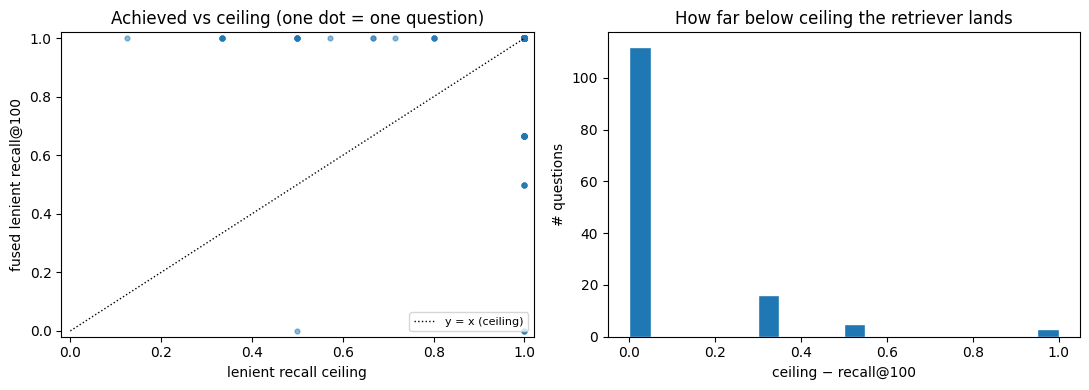

questions at ceiling (gap == 0):  112 / 136
questions with gap ≥ 0.5:         8


In [11]:
k_show = 100
achieved = df[f"fused__lenient__recall@{k_show}"]
ceiling = df["lenient_recall_ceiling"]
gap = (ceiling - achieved).clip(lower=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(ceiling, achieved, s=12, alpha=0.5)
ax[0].plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1, label="y = x (ceiling)")
ax[0].set_xlabel("lenient recall ceiling")
ax[0].set_ylabel(f"fused lenient recall@{k_show}")
ax[0].set_title("Achieved vs ceiling (one dot = one question)")
ax[0].legend(loc="lower right", fontsize=8)
ax[0].set_xlim(-0.02, 1.02); ax[0].set_ylim(-0.02, 1.02)

ax[1].hist(gap, bins=20, edgecolor="white")
ax[1].set_xlabel(f"ceiling − recall@{k_show}")
ax[1].set_ylabel("# questions")
ax[1].set_title("How far below ceiling the retriever lands")
fig.tight_layout()
plt.show()
print(f"questions at ceiling (gap == 0):  {(gap == 0).sum()} / {len(df)}")
print(f"questions with gap ≥ 0.5:         {(gap >= 0.5).sum()}")

## 6. First-relevant-rank distribution

Where in the pool the *first* relevant article appears. This drives MRR and is a useful proxy for how many candidates a downstream reranker has to consider.

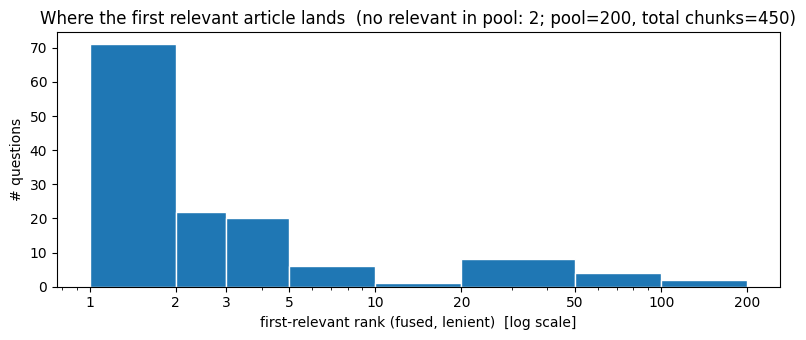

  first-relevant ≤   1:   71 / 136  ( 52.2%)
  first-relevant ≤   5:  114 / 136  ( 83.8%)
  first-relevant ≤  10:  119 / 136  ( 87.5%)
  first-relevant ≤  20:  122 / 136  ( 89.7%)
  first-relevant ≤  50:  128 / 136  ( 94.1%)
  first-relevant ≤ 100:  132 / 136  ( 97.1%)


In [12]:
frr = df["fused__lenient__first_relevant_rank"].fillna(-1)
found = frr[frr > 0]
missing = (frr == -1).sum()

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = [0, 1, 2, 3, 5, 10, 20, 50, 100, 200]
ax.hist(found, bins=bins, edgecolor="white")
ax.set_xscale("log")
ax.set_xticks(bins[1:])
ax.set_xticklabels([str(b) for b in bins[1:]])
ax.set_xlabel("first-relevant rank (fused, lenient)  [log scale]")
ax.set_ylabel("# questions")
ax.set_title(f"Where the first relevant article lands  (no relevant in pool: {missing}; pool=200, total chunks={n_chunks})")
fig.tight_layout()
plt.show()

for cutoff in [1, 5, 10, 20, 50, 100]:
    pct = (found <= cutoff).sum() / len(df) * 100
    print(f"  first-relevant ≤ {cutoff:>3}:  {(found <= cutoff).sum():>3} / {len(df)}  ({pct:5.1f}%)")

## 7. Recall@k curves

Mean recall as a function of pool depth — fused vs dense vs sparse, lenient GT. The dotted vertical line marks the size of the corpus (`n_chunks`); any value of `k` to its right would be saturated.

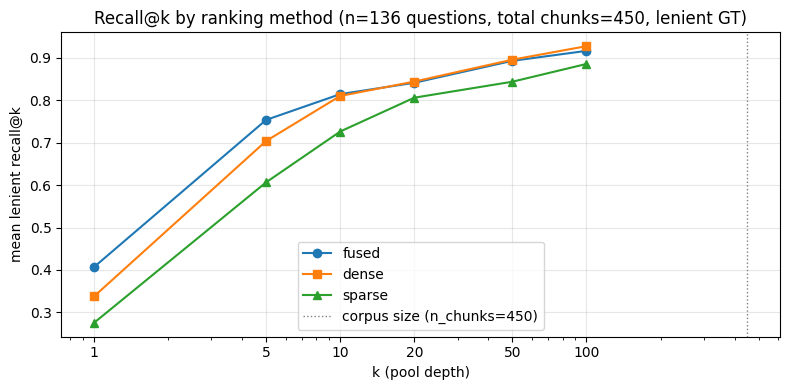

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for ranking, marker in [("fused", "o"), ("dense", "s"), ("sparse", "^")]:
    means = [df[f"{ranking}__lenient__recall@{k}"].mean() for k in K_VALUES]
    ax.plot(K_VALUES, means, marker=marker, label=ranking)
ax.axvline(n_chunks, color="grey", linestyle=":", linewidth=1,
           label=f"corpus size (n_chunks={n_chunks})")
ax.set_xscale("log")
ax.set_xticks(K_VALUES)
ax.set_xticklabels([str(k) for k in K_VALUES])
ax.set_xlabel("k (pool depth)")
ax.set_ylabel("mean lenient recall@k")
ax.set_title(f"Recall@k by ranking method (n={len(df)} questions, total chunks={n_chunks}, lenient GT)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 8. Worst & best cases

A short look at where retrieval struggles and where it sails through, useful as a starting point for qualitative inspection.

In [14]:
worst = (
    df.assign(gap=df["lenient_recall_ceiling"] - df["fused__lenient__recall@100"])
      .sort_values("gap", ascending=False)
      .head(10)
      [["question_id", "split", "per_pdf_extraction_status", "n_lenient",
        "lenient_recall_ceiling", "fused__lenient__recall@100",
        "fused__lenient__first_relevant_rank", "gap"]]
      .reset_index(drop=True)
)
worst.round(3)

,question_id,split,per_pdf_extraction_status,n_lenient,lenient_recall_ceiling,fused__lenient__recall@100,fused__lenient__first_relevant_rank,gap
0,867,test,partial,1,1.0,0.000,152.0,1.000
1,844,train,partial,1,1.0,0.000,NaN,1.000
2,1004,train,partial,1,1.0,0.000,NaN,1.000
3,950,train,partial,2,1.0,0.500,71.0,0.500
4,904,test,mixed,2,1.0,0.500,9.0,0.500
5,843,train,partial,2,1.0,0.500,71.0,0.500
6,745,train,partial,1,0.5,0.000,146.0,0.500
7,903,train,mixed,2,1.0,0.500,20.0,0.500
8,911,train,partial,3,1.0,0.667,1.0,0.333
9,919,train,partial,3,1.0,0.667,1.0,0.333


In [15]:
best = (
    df[df["fused__lenient__recall@10"] >= 0.999]
    .sort_values(["n_lenient", "fused__lenient__first_relevant_rank"], ascending=[False, True])
    .head(10)
    [["question_id", "split", "per_pdf_extraction_status", "n_lenient",
      "fused__lenient__recall@10", "fused__lenient__first_relevant_rank"]]
    .reset_index(drop=True)
)
best

,question_id,split,per_pdf_extraction_status,n_lenient,fused__lenient__recall@10,fused__lenient__first_relevant_rank
0,973,train,partial,6,1.0,1.0
1,981,train,mixed,5,1.0,2.0
2,1005,test,partial,4,1.0,1.0
3,1007,train,partial,4,1.0,1.0
4,1008,train,partial,4,1.0,1.0
5,1013,train,partial,4,1.0,1.0
6,983,test,mixed,4,1.0,2.0
7,1002,test,partial,4,1.0,2.0
8,975,train,mixed,4,1.0,2.0
9,978,train,mixed,4,1.0,2.0


## 9. Save aggregate outputs

Three artifacts beyond the per-question CSV:
- `summary_overall.csv` — one row per (ranking × gt) with mean metrics.
- `summary_by_bucket.csv` — fused/lenient broken down by split and per-PDF bucket.
- `corpus_stats.json` — top-level corpus counts (n_chunks, chunks-with-bsard, unique bsard_ids) for cross-referencing.

In [16]:
overall.to_csv(OUT_DIR / "summary_overall.csv")

split_bucket = grouped(df, ["split", "per_pdf_extraction_status"], "fused", "lenient")
split_bucket.to_csv(OUT_DIR / "summary_by_bucket.csv")

corpus_stats = {
    "doc_id": DOC_ID,
    "config_hash": CONFIG_HASH,
    "n_chunks": n_chunks,
    "n_chunks_with_bsard_ids": n_chunks_with_bsard,
    "n_unique_bsard_ids_in_pdf": len(unique_bsard_ids_in_pdf),
    "pool_depth": POOL_DEPTH,
    "pool_fraction_of_corpus": round(POOL_DEPTH / n_chunks, 4),
    "n_relevant_questions": len(df),
    "chunking": manifest["chunking"],
    "embedding_model": manifest["embedding_model"],
}
with open(OUT_DIR / "corpus_stats.json", "w", encoding="utf-8", newline="\n") as fh:
    json.dump(corpus_stats, fh, ensure_ascii=False, indent=2)
    fh.write("\n")

print("wrote:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.relative_to(HERE)}")
corpus_stats

wrote:
  data\2003_07_17_2013A31614\analysis\corpus_stats.json
  data\2003_07_17_2013A31614\analysis\per_question_metrics.csv
  data\2003_07_17_2013A31614\analysis\summary_by_bucket.csv
  data\2003_07_17_2013A31614\analysis\summary_overall.csv


{'doc_id': '2003_07_17_2013A31614',
 'config_hash': '614cc9425f5f',
 'n_chunks': 450,
 'n_chunks_with_bsard_ids': 438,
 'n_unique_bsard_ids_in_pdf': 237,
 'pool_depth': 200,
 'pool_fraction_of_corpus': 0.4444,
 'n_relevant_questions': 136,
 'chunking': {'strategy': 'sliding_window', 'window_size': 512, 'stride': 256},
 'embedding_model': 'intfloat/multilingual-e5-large-instruct'}

## 10. Caveats

- **Single config.** Only `5edcd3a09e09` (sliding window 512/256, e5-large-instruct) is analysed. The other cached config (`0078c56c8507`) has no retrieval pool yet.
- **No reranker.** The cross-encoder reranker was removed from the RQ2 architecture on 2026-05-25 (see RQ2_T04_ARM2_METADATA/CHANGE_NOTES.md, session "cross-encoder removed from RQ2 architecture"). The RRF-fused pool *is* the production retrieval output for Arm 1; no rerank stage exists downstream.
- **Article-level, unweighted.** A chunk overlapping one GT article counts the same regardless of how much of the article it actually covers. The proper weighted metrics (T07's `chunk_bsard_weights`) would discount partial overlaps.
- **Strict ceiling = 0 for `partial` bucket** by construction. Use lenient when comparing across buckets.
- **Pool depth vs corpus.** Pool is 200 chunks per question out of `n_chunks` total. The fraction is printed in §1 — at >25% it's no longer a tight retrieval bottleneck, so improvements from a deeper pool will be small.